# Predefined Epidemic Models
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/epistorm/epydemix/blob/main/tutorials/12_Predefined_Models.ipynb)

If you are running this tutorial on Google Colab, you can install the needed packages by running the following cell:

In [1]:
import sys, os, subprocess
if "google.colab" in sys.modules or os.getenv("COLAB_RELEASE_TAG"):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    "https://raw.githubusercontent.com/epistorm/epydemix/refs/heads/main/tutorials/colab_requirements.txt"])

**epydemix** ships with a library of ready-to-use epidemic models that can be loaded with a single call to `load_predefined_model`. This tutorial covers:

1. **Backbone models** — the structural archetypes: SIR, SEIR, SIS, SEIAR
2. **Modular extensions** — orthogonal additions that can be composed on any backbone:
   - Waning immunity
   - Vaccination
   - Outcome tracking (deaths or hospitalization)
3. **Combining modules** — how to stack multiple extensions
4. **Overriding parameters after construction** — including age-varying and time-varying rates

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles

## 1. Backbone Models

A backbone is the core compartmental structure of a model. Four backbones are available.

| Backbone | Compartments | Key feature |
|----------|-------------|-------------|
| `SIR`    | S → I → R   | Classic, permanent immunity |
| `SEIR`   | S → E → I → R | Latent (exposed) period before infectiousness |
| `SIS`    | S → I → S   | No immunity — repeated reinfection |
| `SEIAR`  | S → E → {I, A} → R | Asymptomatic pathway with reduced infectivity |

All backbones share three core parameters:

- `transmission_rate` — rate of transmission from an infectious contact  
- `recovery_rate` — rate at which symptomatic infected individuals recover  
- `incubation_rate` — rate of progression from Exposed to Infected (SEIR and SEIAR only)

### SIR

In [3]:
sir = load_predefined_model("SIR", transmission_rate=0.3, recovery_rate=0.1)
print(sir)

EpiModel(name='EpiModel')
Compartments: 3
  Susceptible, Infected, Recovered
Transitions: 2
  Transitions between compartments:
    Susceptible -> Infected, params: ('transmission_rate', 'Infected') (kind: mediated)
    Infected -> Recovered, params: recovery_rate (kind: spontaneous)
Parameters: 2
  Model parameters:
    transmission_rate: 0.3
    recovery_rate: 0.1
Population: epydemix_population
  Population size: 100000 individuals
  Demographic groups: 1
    0



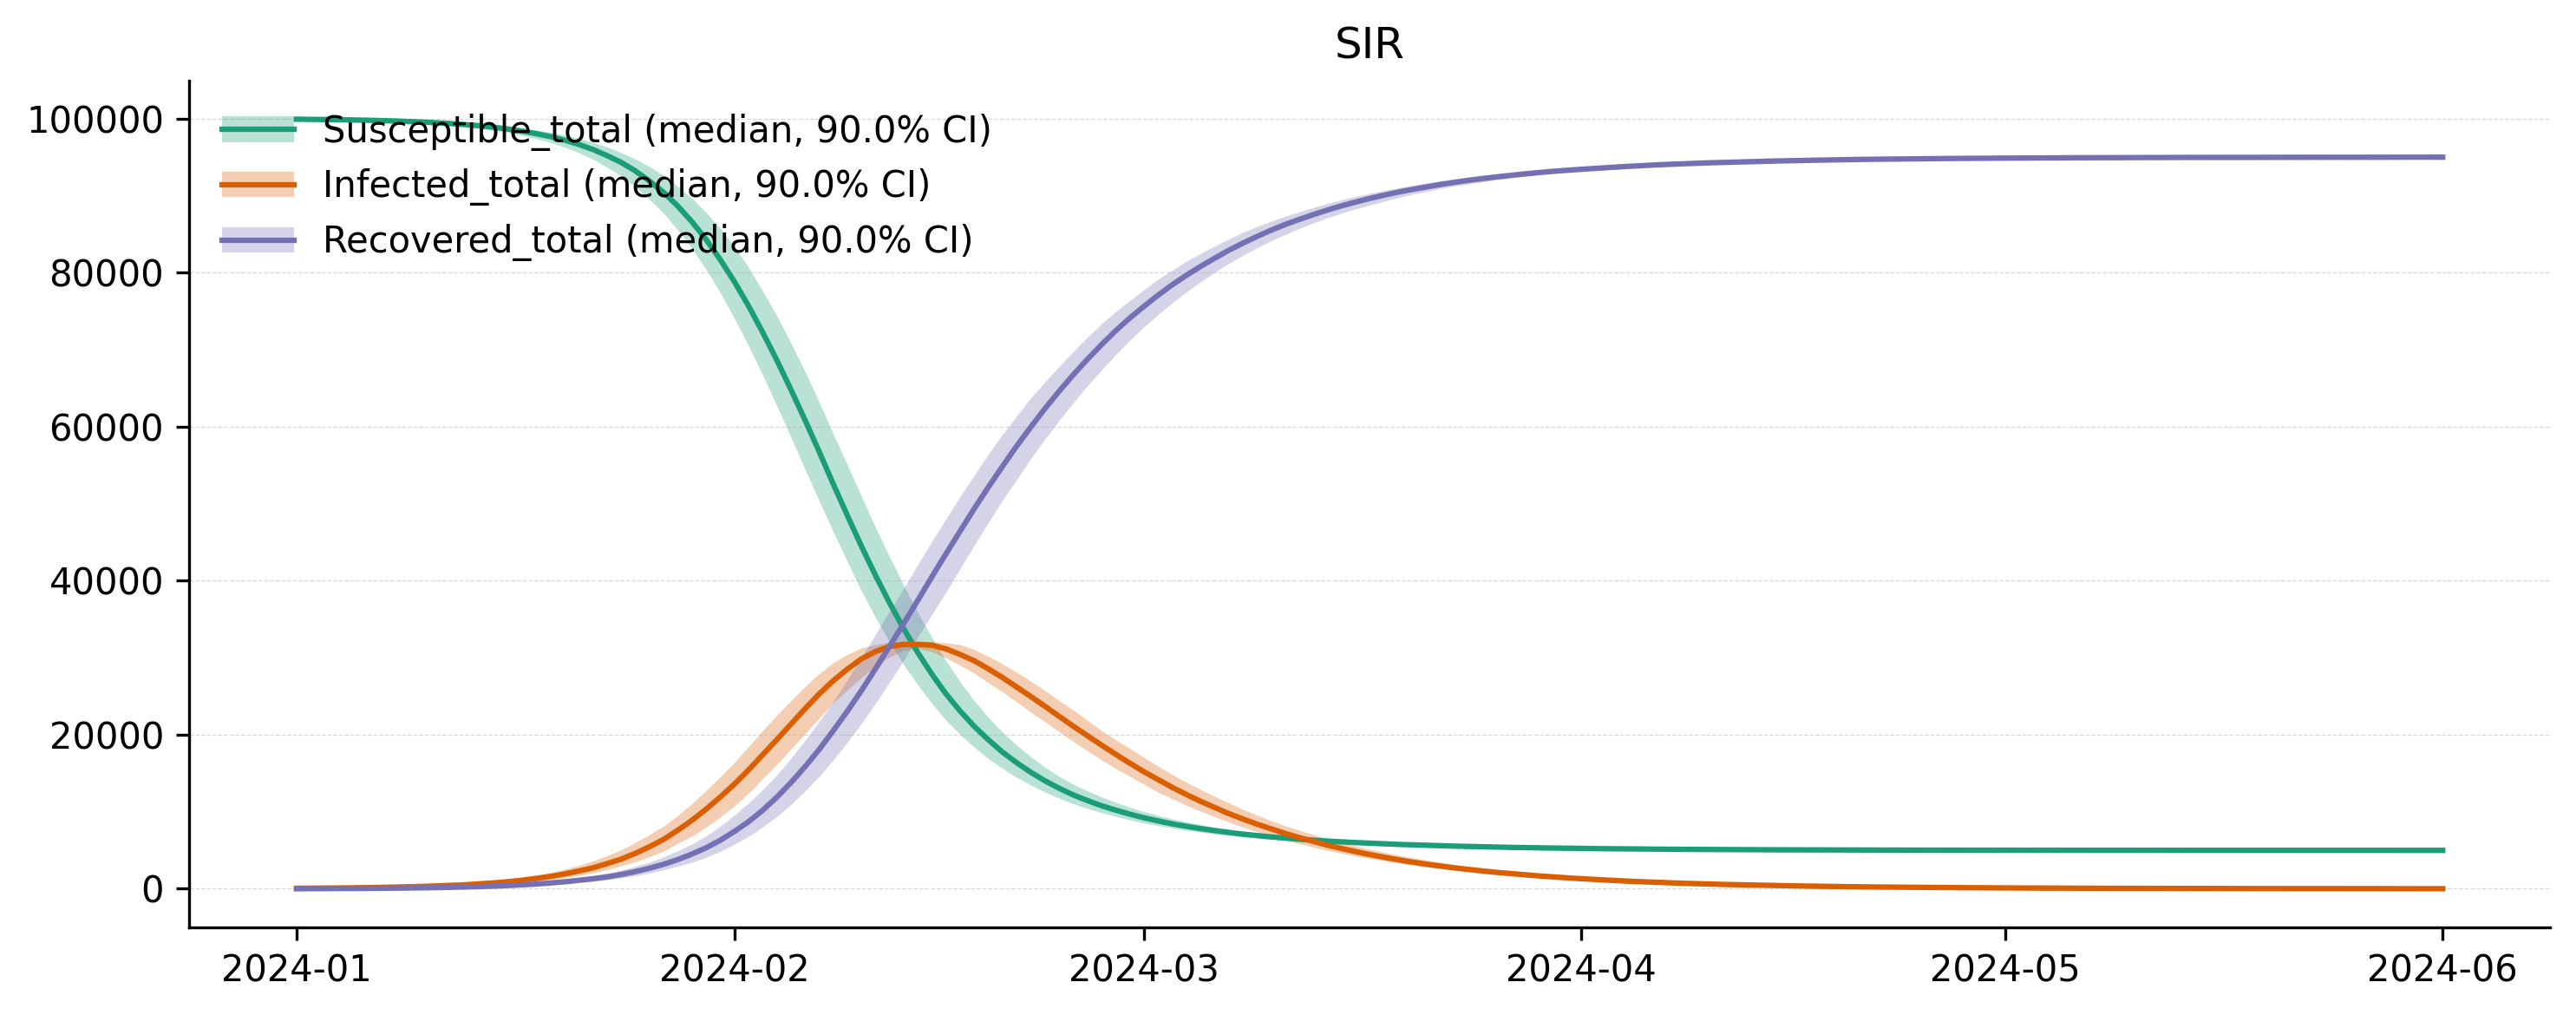

In [4]:
sir_results = sir.run_simulations(start_date="2024-01-01", end_date="2024-06-01")
df = sir_results.get_quantiles_compartments()
plot_quantiles(df, columns=["Susceptible_total", "Infected_total", "Recovered_total"],
               title="SIR");

### SEIR

The SEIR model adds an **Exposed** compartment. Individuals who are exposed are not yet infectious — they transition to Infected at the `incubation_rate`.

In [5]:
seir = load_predefined_model("SEIR", transmission_rate=0.3, incubation_rate=0.2, recovery_rate=0.1)
print(seir)

EpiModel(name='EpiModel')
Compartments: 4
  Susceptible, Exposed, Infected, Recovered
Transitions: 3
  Transitions between compartments:
    Susceptible -> Exposed, params: ('transmission_rate', 'Infected') (kind: mediated)
    Exposed -> Infected, params: incubation_rate (kind: spontaneous)
    Infected -> Recovered, params: recovery_rate (kind: spontaneous)
Parameters: 3
  Model parameters:
    transmission_rate: 0.3
    incubation_rate: 0.2
    recovery_rate: 0.1
Population: epydemix_population
  Population size: 100000 individuals
  Demographic groups: 1
    0



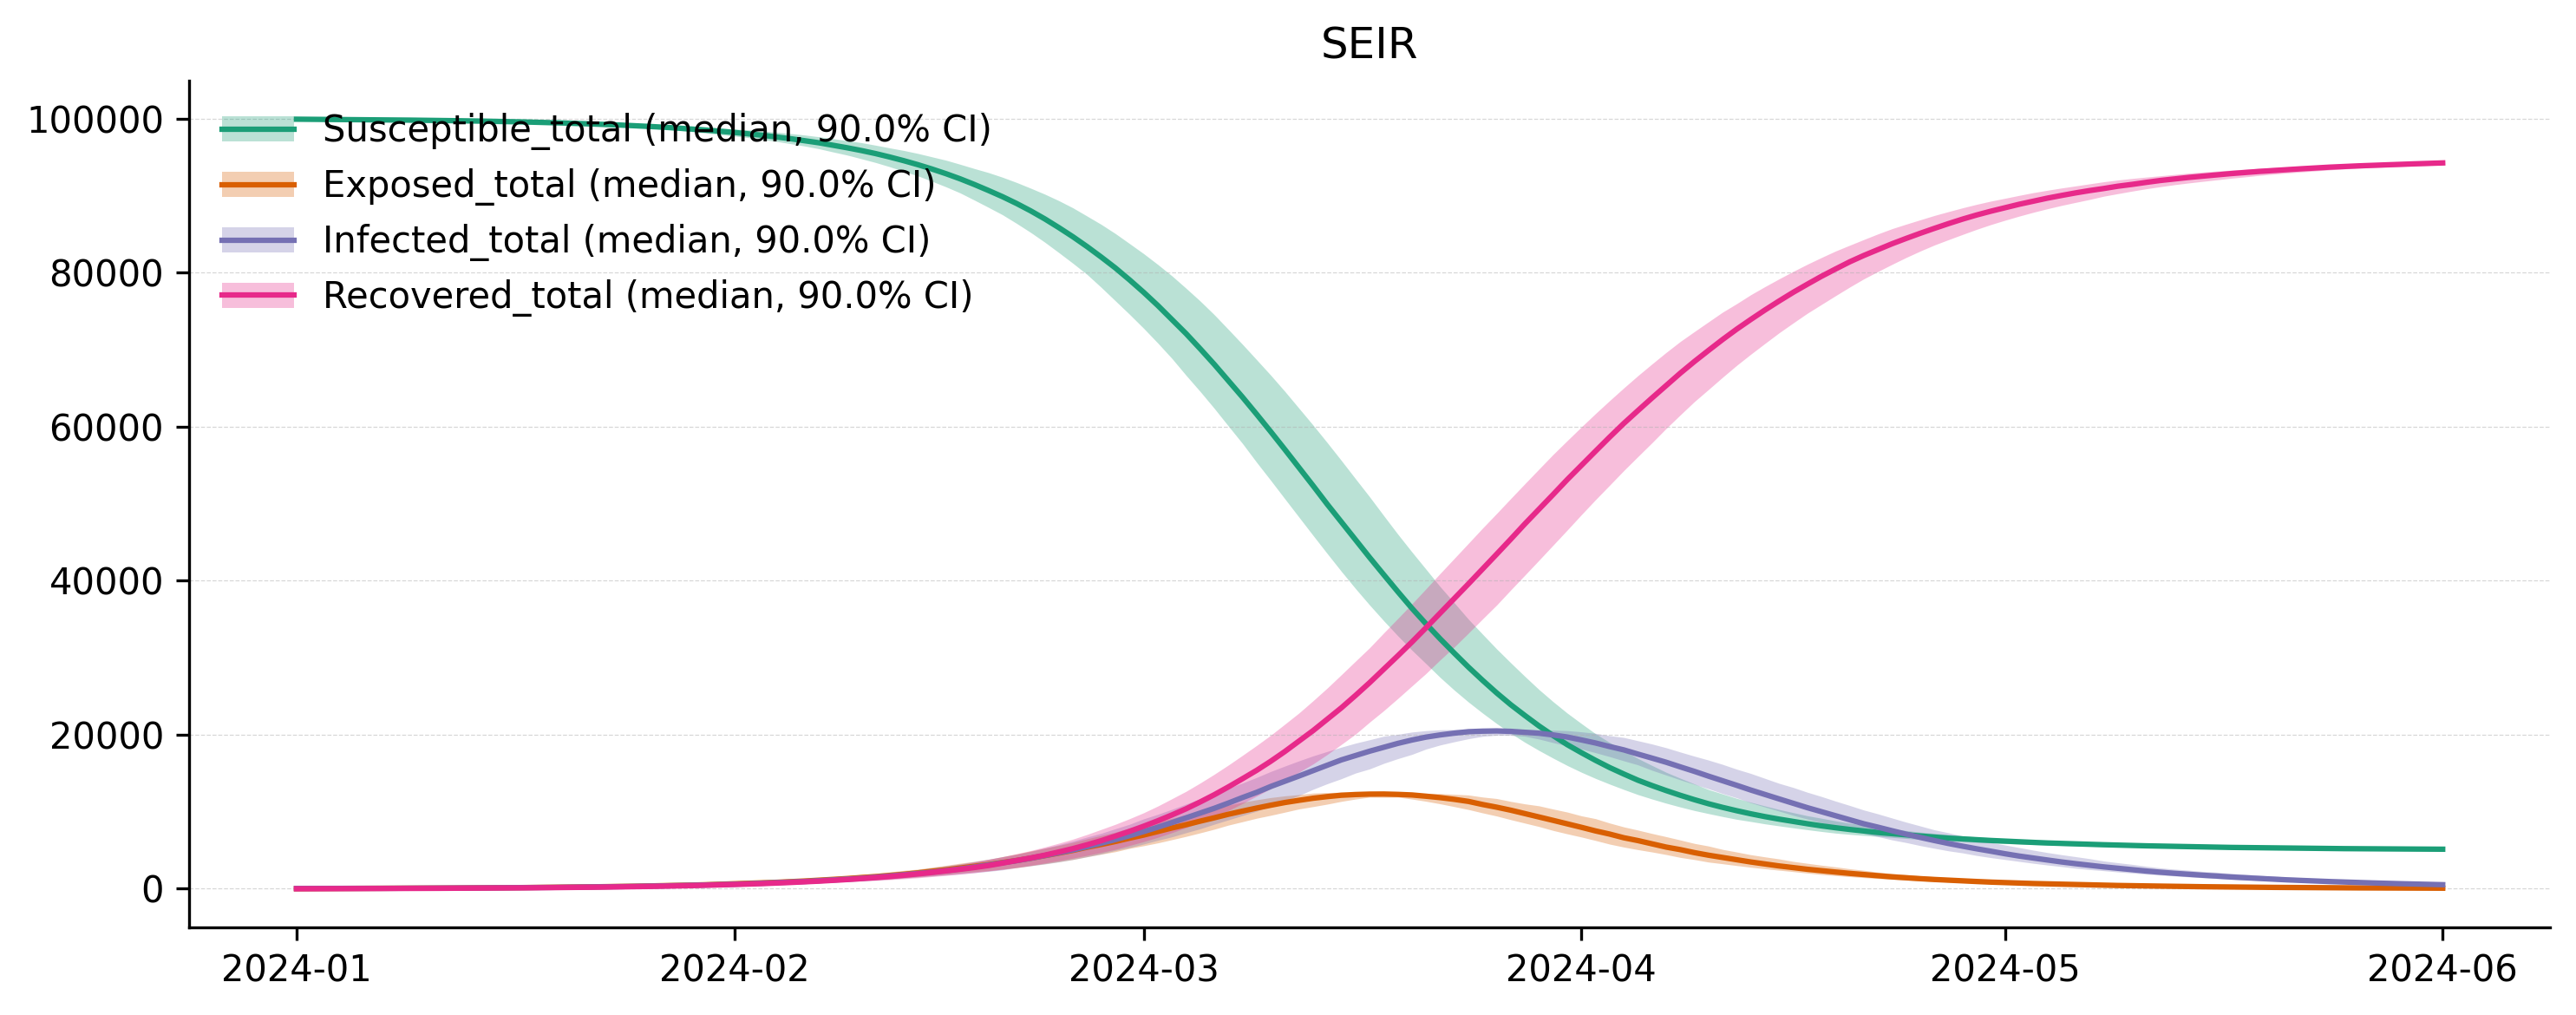

In [6]:
seir_results = seir.run_simulations(start_date="2024-01-01", end_date="2024-06-01")
df = seir_results.get_quantiles_compartments()
plot_quantiles(df, columns=["Susceptible_total", "Exposed_total", "Infected_total", "Recovered_total"],
               title="SEIR");

### SIS

In the SIS model recovery returns individuals to the **Susceptible** pool — there is no lasting immunity. This is appropriate for diseases like seasonal influenza strains or many bacterial infections.

In [7]:
sis = load_predefined_model("SIS", transmission_rate=0.3, recovery_rate=0.1)
print(sis)

EpiModel(name='EpiModel')
Compartments: 2
  Susceptible, Infected
Transitions: 2
  Transitions between compartments:
    Susceptible -> Infected, params: ('transmission_rate', 'Infected') (kind: mediated)
    Infected -> Susceptible, params: recovery_rate (kind: spontaneous)
Parameters: 2
  Model parameters:
    transmission_rate: 0.3
    recovery_rate: 0.1
Population: epydemix_population
  Population size: 100000 individuals
  Demographic groups: 1
    0



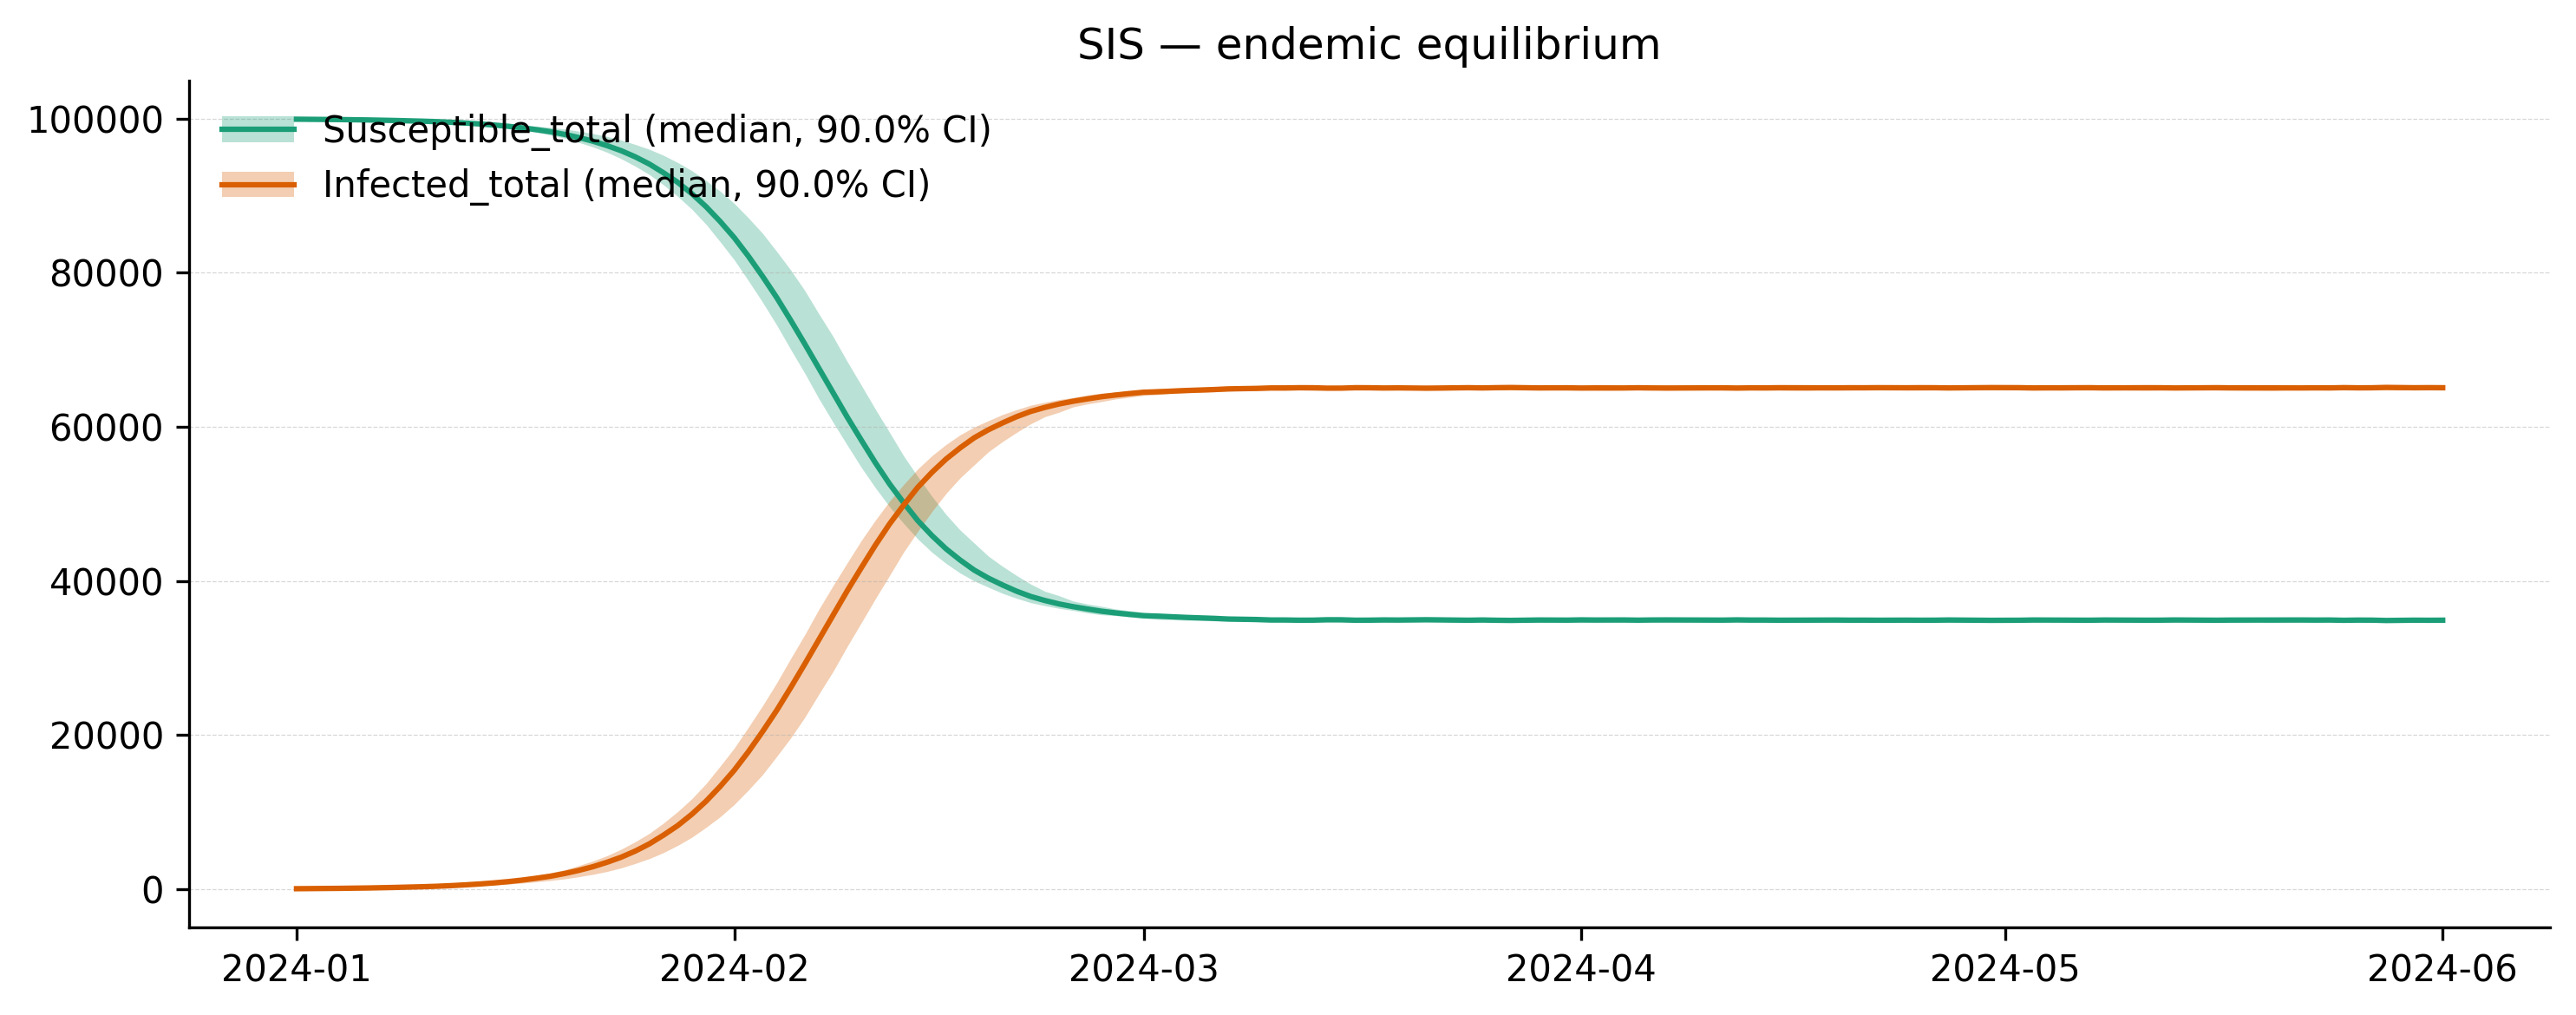

In [8]:
sis_results = sis.run_simulations(start_date="2024-01-01", end_date="2024-06-01")
df = sis_results.get_quantiles_compartments()
plot_quantiles(df, columns=["Susceptible_total", "Infected_total"],
               title="SIS — endemic equilibrium");

### SEIAR — Asymptomatic Transmission

SEIAR extends SEIR with an **Asymptomatic** infectious pathway. After the exposed period, a fraction `asymptomatic_fraction` of individuals become asymptomatic (A) rather than symptomatic (I). Asymptomatics are infectious but at a reduced rate controlled by `asymptomatic_relative_infectivity`.

SEIAR-specific parameters:

| Parameter | Meaning | Default |
|-----------|---------|--------|
| `asymptomatic_fraction` | Fraction of exposed who become asymptomatic | 0.4 |
| `asymptomatic_recovery_rate` | Recovery rate for asymptomatic individuals | 0.14 |
| `asymptomatic_relative_infectivity` | Infectivity of A relative to I | 0.5 |

In [11]:
seiar = load_predefined_model(
    "SEIAR",
    transmission_rate=0.35,
    incubation_rate=0.2,
    recovery_rate=0.1,
    asymptomatic_fraction=0.4,
    asymptomatic_recovery_rate=0.14,
    asymptomatic_relative_infectivity=0.5,
)
print(seiar)

EpiModel(name='EpiModel')
Compartments: 5
  Susceptible, Exposed, Infected, Asymptomatic, Recovered
Transitions: 6
  Transitions between compartments:
    Susceptible -> Exposed, params: ('transmission_rate', 'Infected') (kind: mediated)
    Susceptible -> Exposed, params: ('transmission_rate * asymptomatic_relative_infectivity', 'Asymptomatic') (kind: mediated)
    Exposed -> Infected, params: incubation_rate * (1 - asymptomatic_fraction) (kind: spontaneous)
    Exposed -> Asymptomatic, params: incubation_rate * asymptomatic_fraction (kind: spontaneous)
    Infected -> Recovered, params: recovery_rate (kind: spontaneous)
    Asymptomatic -> Recovered, params: asymptomatic_recovery_rate (kind: spontaneous)
Parameters: 6
  Model parameters:
    transmission_rate: 0.35
    incubation_rate: 0.2
    recovery_rate: 0.1
    asymptomatic_fraction: 0.4
    asymptomatic_recovery_rate: 0.14
    asymptomatic_relative_infectivity: 0.5
Population: epydemix_population
  Population size: 100000 indiv

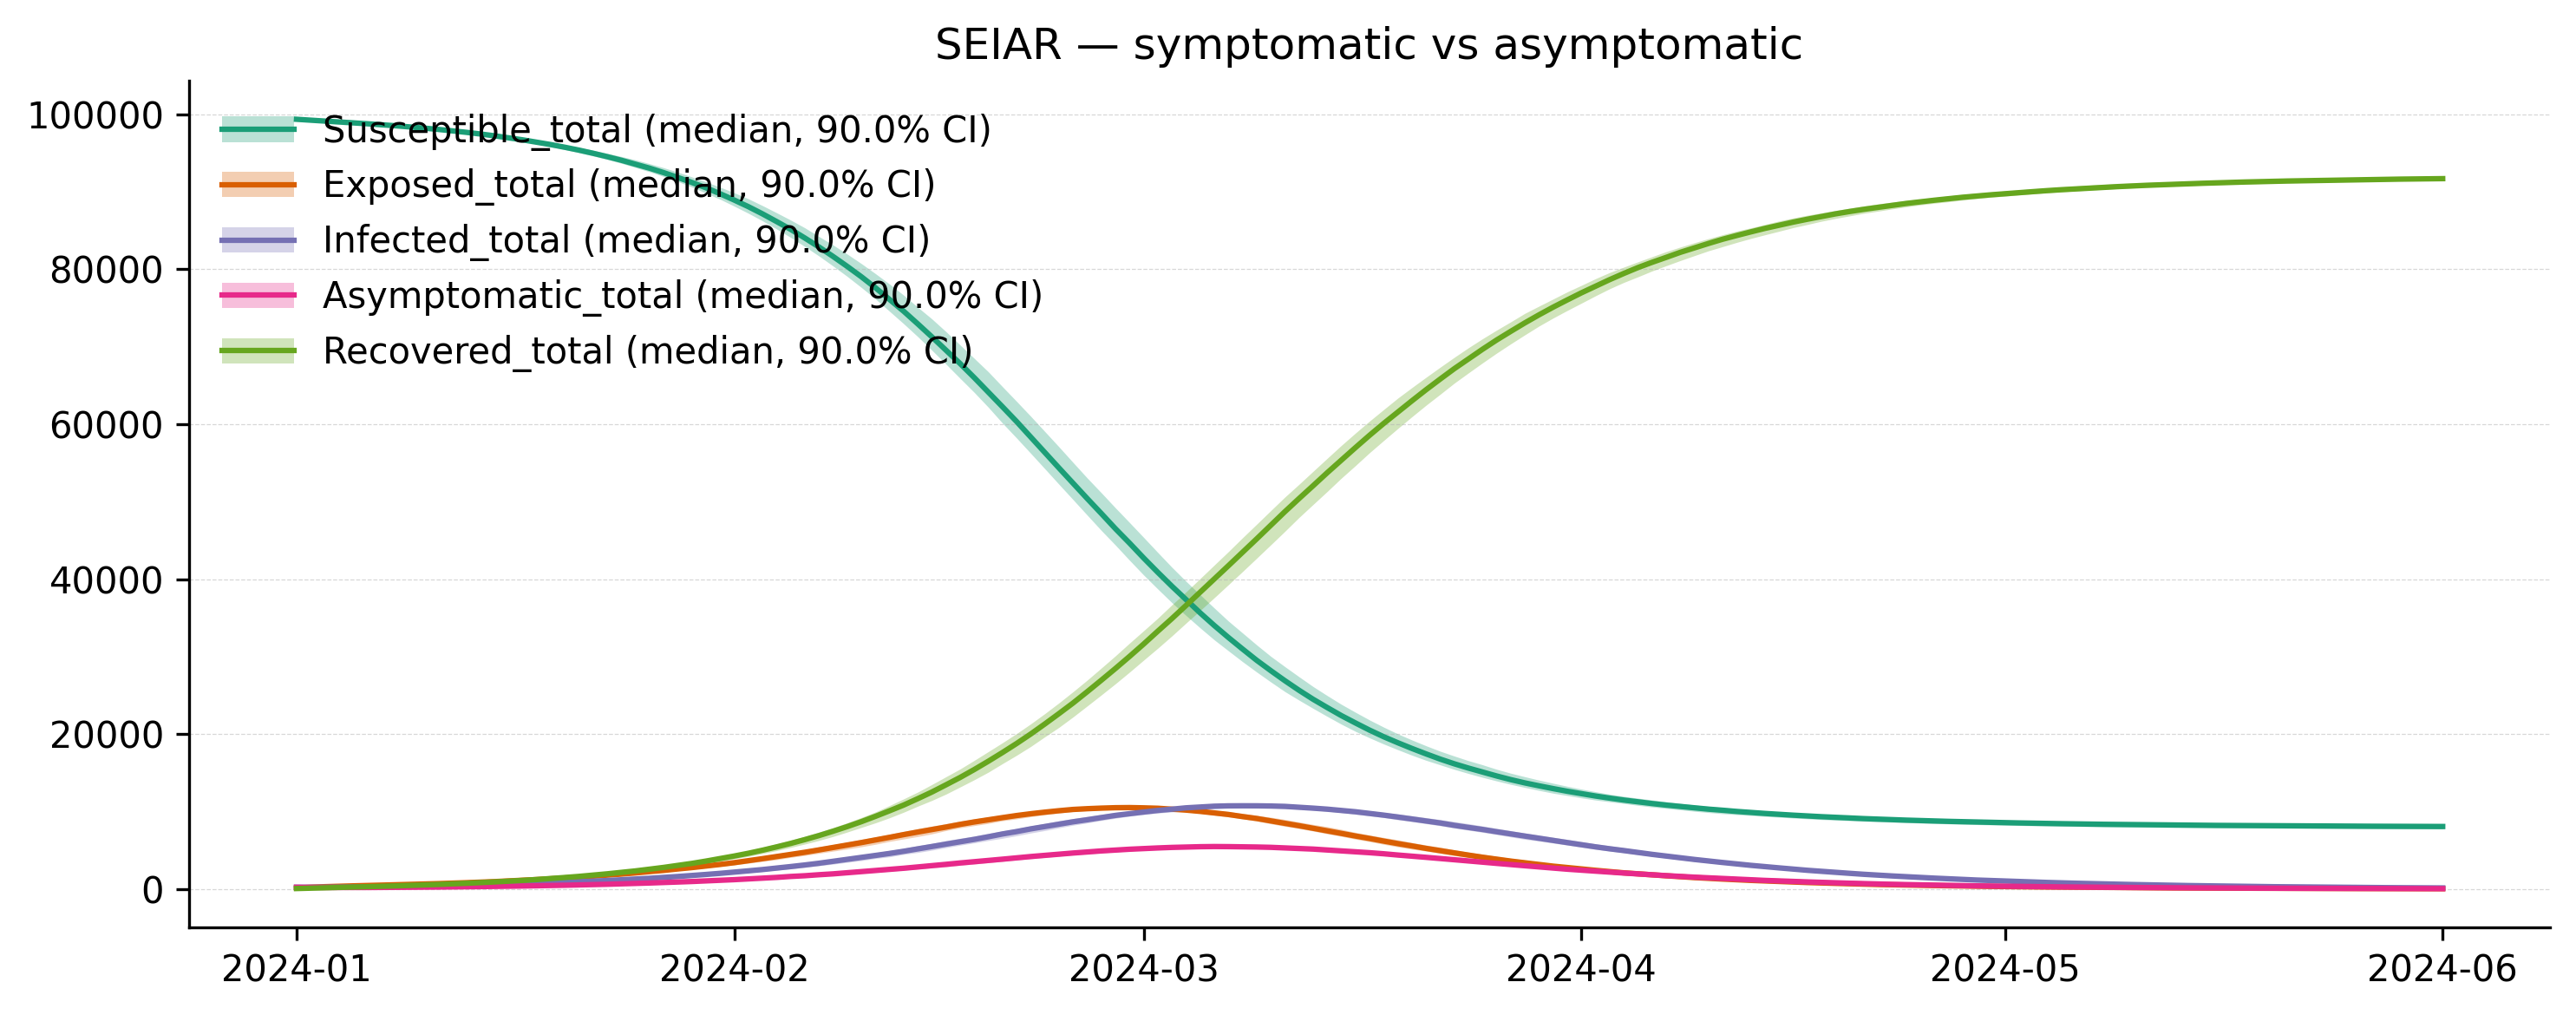

In [12]:
seiar_results = seiar.run_simulations(start_date="2024-01-01", end_date="2024-06-01", percentage_in_agents=0.005)
df = seiar_results.get_quantiles_compartments()
plot_quantiles(
    df,
    columns=["Susceptible_total", "Exposed_total", "Infected_total", "Asymptomatic_total", "Recovered_total"],
    title="SEIAR — symptomatic vs asymptomatic",
);

## 2. Modular Extensions

Modular extensions add compartments and transitions on top of any backbone. They are activated by keyword arguments on `load_predefined_model` — no need to build a new model from scratch.

The three available modules are:

| Module | Flag | What it adds |
|--------|------|--------------|
| Waning immunity | `waning_immunity=True` | R → S spontaneous transition |
| Vaccination | `vaccination=True` | Vaccinated compartment, S → V → I/E at reduced rate (E if backbone has an Exposed compartment) |
| Outcome | `outcome="deaths"` or `outcome="hospitalization"` | Dead or Hospitalized compartment branching from I |

Each module has its own rate parameters with sensible defaults that can be overridden.

### 2.1 Waning Immunity

Setting `waning_immunity=True` adds an **R → S** transition. Individuals who have recovered gradually lose immunity and return to the susceptible pool, producing SIRS or SEIRS dynamics.

The `waning_rate` controls the speed of immunity loss and is expressed as the **inverse of the average immunity duration in days**. The default `1/365` corresponds to approximately one year of immunity.

In [13]:
# SIRS: SIR backbone + waning immunity
sirs = load_predefined_model(
    "SIR",
    transmission_rate=0.3,
    recovery_rate=0.1,
    waning_immunity=True,
    waning_rate=1.0 / 180,   # ~6 months of immunity
)
print(sirs)

EpiModel(name='EpiModel')
Compartments: 3
  Susceptible, Infected, Recovered
Transitions: 3
  Transitions between compartments:
    Susceptible -> Infected, params: ('transmission_rate', 'Infected') (kind: mediated)
    Infected -> Recovered, params: recovery_rate (kind: spontaneous)
    Recovered -> Susceptible, params: waning_rate (kind: spontaneous)
Parameters: 3
  Model parameters:
    transmission_rate: 0.3
    recovery_rate: 0.1
    waning_rate: 0.005555555555555556
Population: epydemix_population
  Population size: 100000 individuals
  Demographic groups: 1
    0



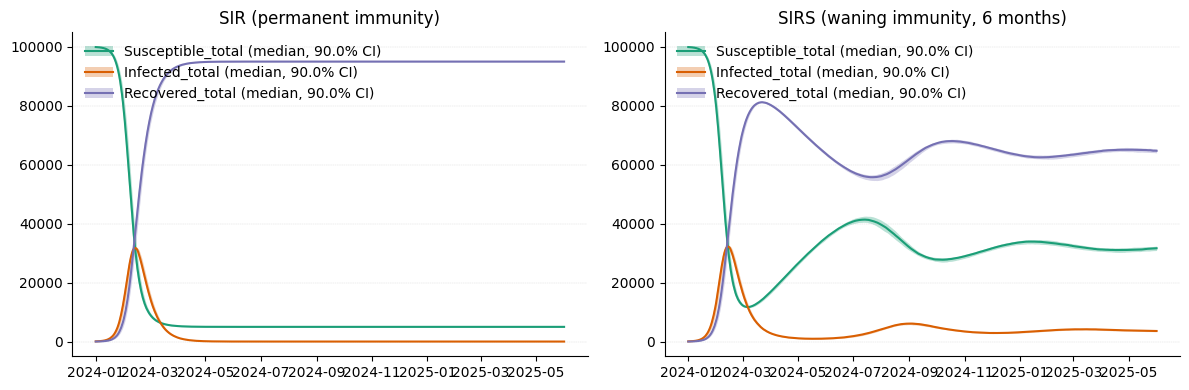

In [14]:
# Run over a longer horizon to see reinfection waves
sir_results  = load_predefined_model("SIR",  transmission_rate=0.3, recovery_rate=0.1
                                     ).run_simulations(start_date="2024-01-01", end_date="2025-06-01")
sirs_results = sirs.run_simulations(start_date="2024-01-01", end_date="2025-06-01")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_quantiles(sir_results.get_quantiles_compartments(),
               columns=["Susceptible_total", "Infected_total", "Recovered_total"],
               title="SIR (permanent immunity)", ax=axes[0])
plot_quantiles(sirs_results.get_quantiles_compartments(),
               columns=["Susceptible_total", "Infected_total", "Recovered_total"],
               title="SIRS (waning immunity, 6 months)", ax=axes[1])
plt.tight_layout();

The SIRS model reaches an **endemic equilibrium** rather than dying out, because the returning susceptibles sustain repeated transmission waves.

> **Note:** `waning_immunity=True` is not compatible with `SIS` (which has no Recovered compartment) and will raise a `ValueError`.

### 2.2 Vaccination

Setting `vaccination=True` adds a **Vaccinated** compartment with two transitions:
- `S → Vaccinated` (spontaneous, rate `vaccination_rate`)
- `Vaccinated → Infected` (mediated by Infected, rate `transmission_rate * (1 - vaccine_efficacy)`) — or `Vaccinated → Exposed` if the backbone has an Exposed compartment (SEIR, SEIAR), so breakthrough infections re-enter the incubation stage

Vaccinated individuals can still get infected, but at a reduced rate proportional to `(1 - vaccine_efficacy)`.

In [15]:
# SEIR-V: SEIR backbone + vaccination
seir_v = load_predefined_model(
    "SEIR",
    transmission_rate=0.3,
    incubation_rate=0.2,
    recovery_rate=0.1,
    vaccination=True,
    vaccination_rate=0.005,   # 0.5% of susceptibles vaccinated per day
    vaccine_efficacy=0.85,
)
print(seir_v)

EpiModel(name='EpiModel')
Compartments: 5
  Susceptible, Exposed, Infected, Recovered, Vaccinated
Transitions: 5
  Transitions between compartments:
    Susceptible -> Exposed, params: ('transmission_rate', 'Infected') (kind: mediated)
    Exposed -> Infected, params: incubation_rate (kind: spontaneous)
    Infected -> Recovered, params: recovery_rate (kind: spontaneous)
    Susceptible -> Vaccinated, params: vaccination_rate (kind: spontaneous)
    Vaccinated -> Exposed, params: ('transmission_rate * (1 - vaccine_efficacy)', 'Infected') (kind: mediated)
Parameters: 5
  Model parameters:
    transmission_rate: 0.3
    incubation_rate: 0.2
    recovery_rate: 0.1
    vaccination_rate: 0.005
    vaccine_efficacy: 0.85
Population: epydemix_population
  Population size: 100000 individuals
  Demographic groups: 1
    0



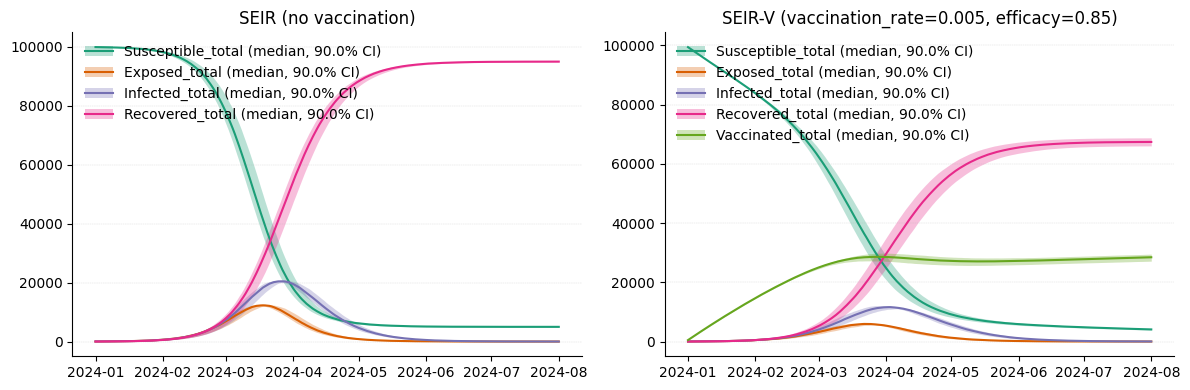

In [16]:
seir_results  = load_predefined_model("SEIR", transmission_rate=0.3, incubation_rate=0.2, recovery_rate=0.1
                                      ).run_simulations(start_date="2024-01-01", end_date="2024-08-01")
seir_v_results = seir_v.run_simulations(start_date="2024-01-01", end_date="2024-08-01")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_quantiles(seir_results.get_quantiles_compartments(),
               columns=["Susceptible_total", "Exposed_total", "Infected_total", "Recovered_total"],
               title="SEIR (no vaccination)", ax=axes[0])
plot_quantiles(seir_v_results.get_quantiles_compartments(),
               columns=["Susceptible_total", "Exposed_total", "Infected_total",
                        "Recovered_total", "Vaccinated_total"],
               title="SEIR-V (vaccination_rate=0.005, efficacy=0.85)", ax=axes[1])
plt.tight_layout();

### 2.3 Outcome Tracking

The `outcome` argument adds a terminal or absorbing branch from the **Infected** compartment. Two outcomes are supported:

- `outcome="deaths"` — adds a **Dead** compartment. Rate parameter: `mortality_rate`.
- `outcome="hospitalization"` — adds a **Hospitalized** compartment with two transitions: `I → Hospitalized` and `Hospitalized → Recovered`. Rate parameters: `hospitalization_rate`, `hospitalization_recovery_rate`.

Only one outcome can be active at a time.

In [17]:
# SIRD
sird = load_predefined_model(
    "SIR",
    transmission_rate=0.3,
    recovery_rate=0.1,
    outcome="deaths",
    mortality_rate=0.005,
)
print(sird)

EpiModel(name='EpiModel')
Compartments: 4
  Susceptible, Infected, Recovered, Dead
Transitions: 3
  Transitions between compartments:
    Susceptible -> Infected, params: ('transmission_rate', 'Infected') (kind: mediated)
    Infected -> Recovered, params: recovery_rate (kind: spontaneous)
    Infected -> Dead, params: mortality_rate (kind: spontaneous)
Parameters: 3
  Model parameters:
    transmission_rate: 0.3
    recovery_rate: 0.1
    mortality_rate: 0.005
Population: epydemix_population
  Population size: 100000 individuals
  Demographic groups: 1
    0



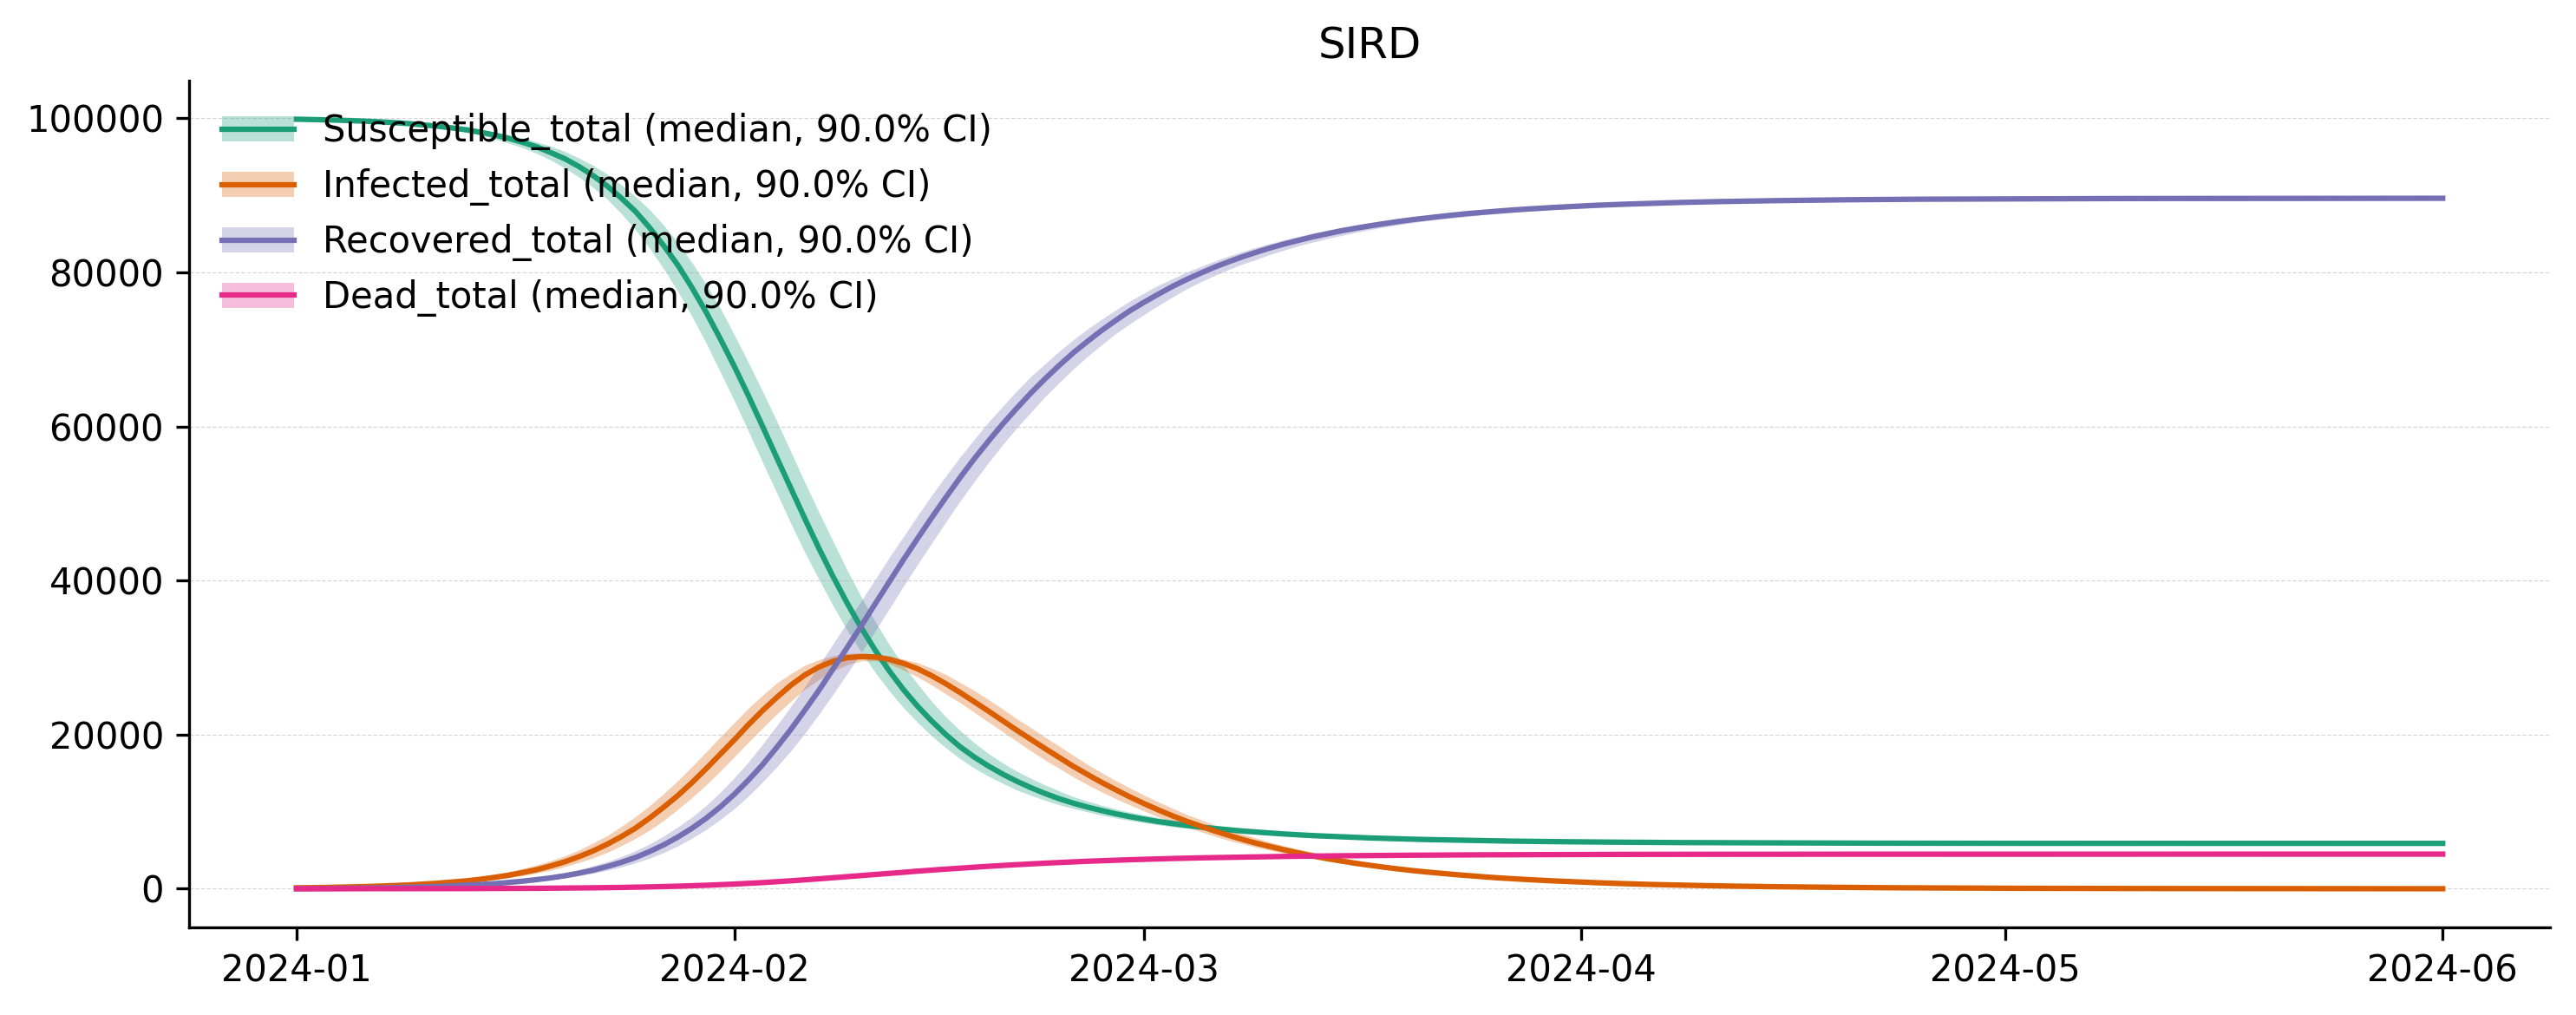

In [18]:
sird_results = sird.run_simulations(
    start_date="2024-01-01",
    end_date="2024-06-01",
    initial_conditions_dict={
        "Susceptible": np.array([99900]),
        "Infected": np.array([100]),
        "Recovered": np.array([0]),
        "Dead": np.array([0]),
    },
)
df = sird_results.get_quantiles_compartments()
plot_quantiles(df,
               columns=["Susceptible_total", "Infected_total", "Recovered_total", "Dead_total"],
               title="SIRD");

In [19]:
# SEIRH — SEIR with hospitalization
seirh = load_predefined_model(
    "SEIR",
    transmission_rate=0.3,
    incubation_rate=0.2,
    recovery_rate=0.1,
    outcome="hospitalization",
    hospitalization_rate=0.02,
    hospitalization_recovery_rate=0.05,
)
print(seirh)

EpiModel(name='EpiModel')
Compartments: 5
  Susceptible, Exposed, Infected, Recovered, Hospitalized
Transitions: 5
  Transitions between compartments:
    Susceptible -> Exposed, params: ('transmission_rate', 'Infected') (kind: mediated)
    Exposed -> Infected, params: incubation_rate (kind: spontaneous)
    Infected -> Recovered, params: recovery_rate (kind: spontaneous)
    Infected -> Hospitalized, params: hospitalization_rate (kind: spontaneous)
    Hospitalized -> Recovered, params: hospitalization_recovery_rate (kind: spontaneous)
Parameters: 5
  Model parameters:
    transmission_rate: 0.3
    incubation_rate: 0.2
    recovery_rate: 0.1
    hospitalization_rate: 0.02
    hospitalization_recovery_rate: 0.05
Population: epydemix_population
  Population size: 100000 individuals
  Demographic groups: 1
    0



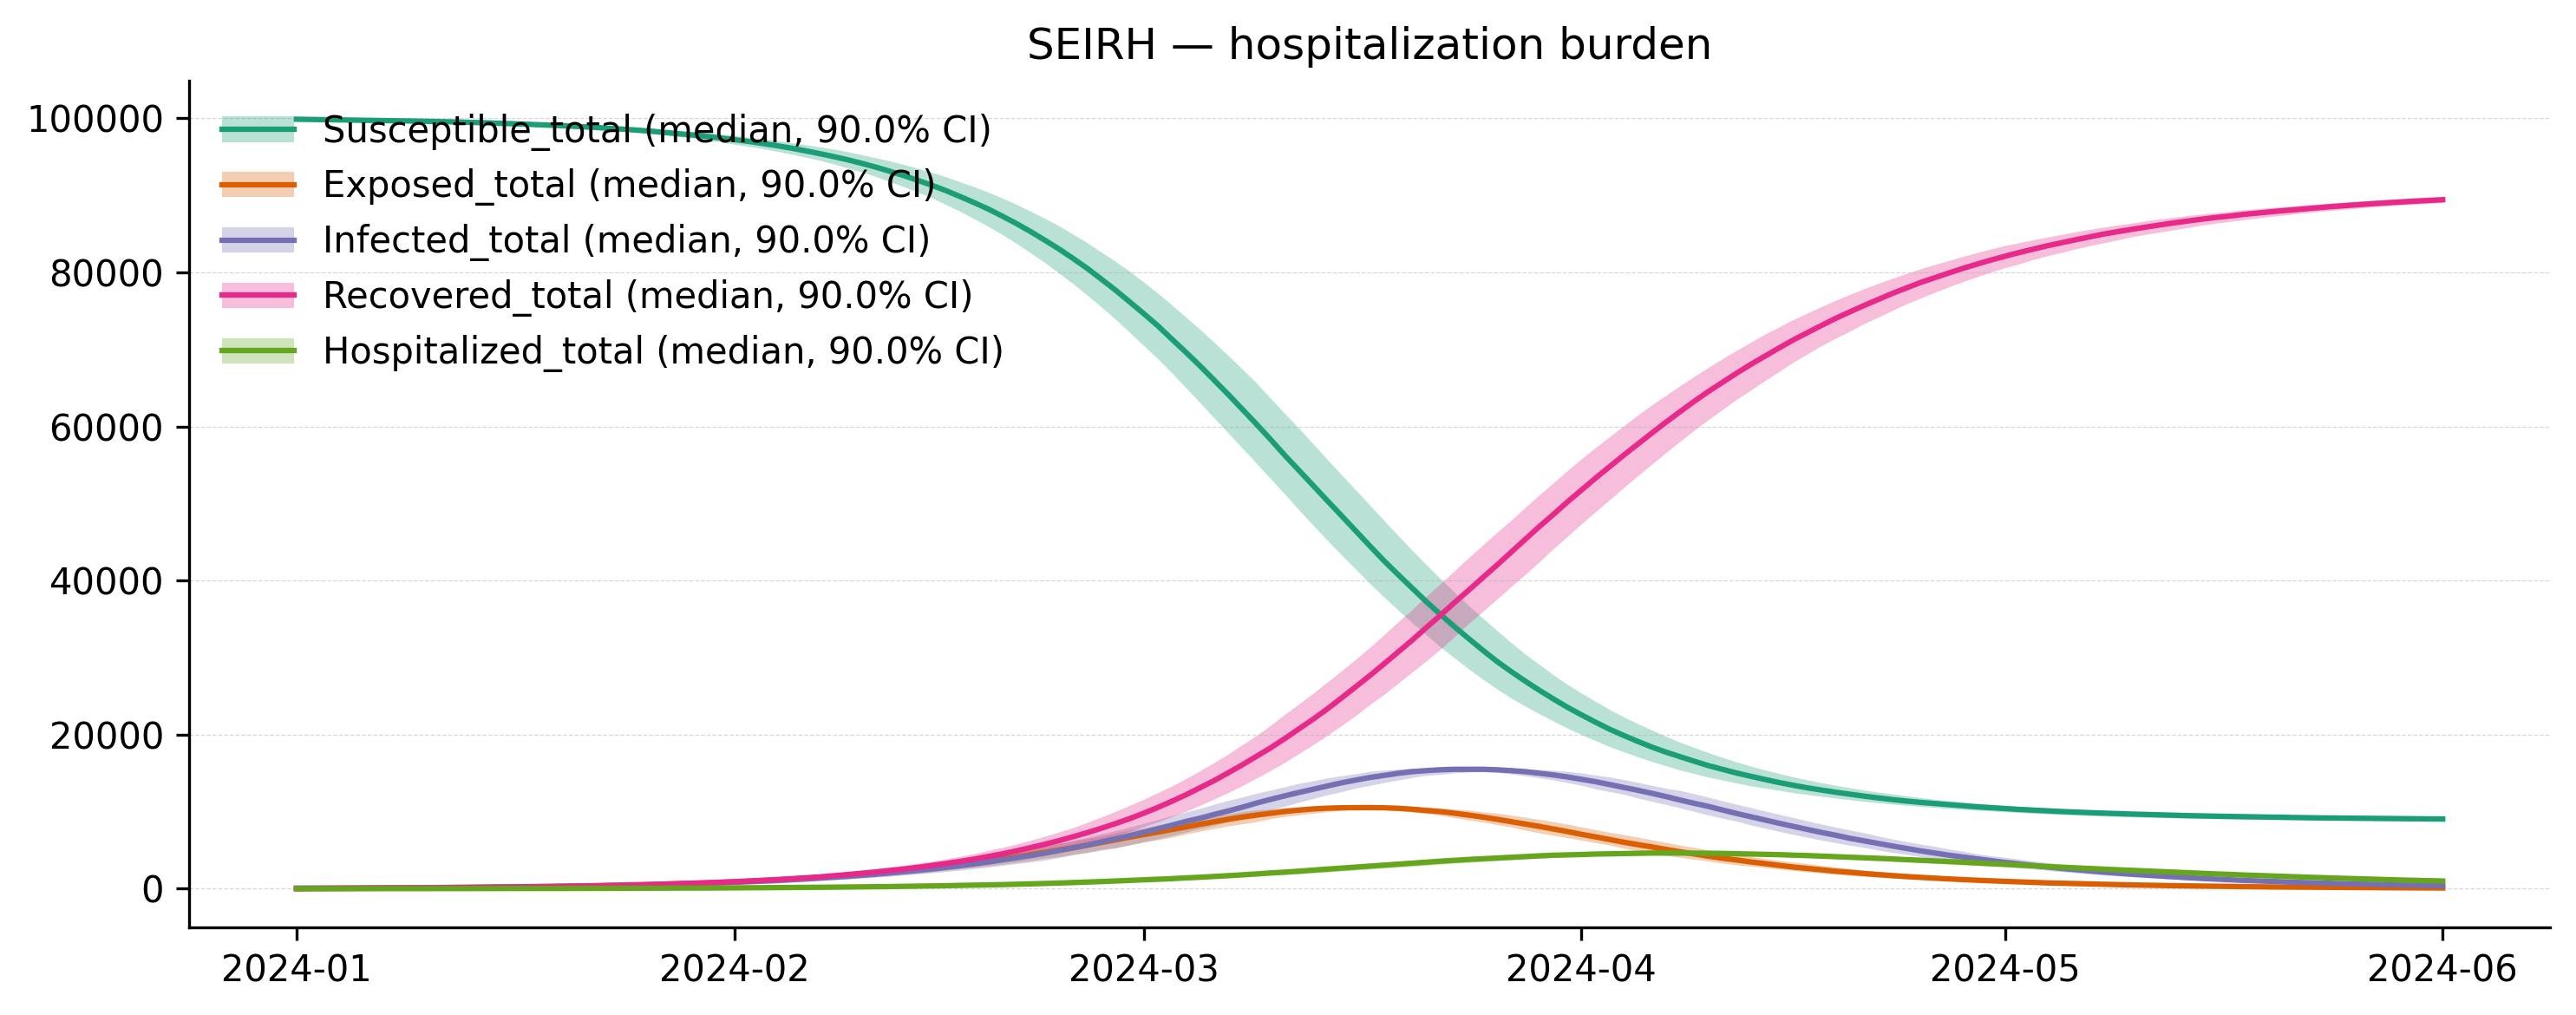

In [20]:
seirh_results = seirh.run_simulations(
    start_date="2024-01-01",
    end_date="2024-06-01",
    initial_conditions_dict={
        "Susceptible": np.array([99900]),
        "Exposed": np.array([0]),
        "Infected": np.array([100]),
        "Recovered": np.array([0]),
        "Hospitalized": np.array([0]),
    },
)
df = seirh_results.get_quantiles_compartments()
plot_quantiles(
    df,
    columns=["Susceptible_total", "Exposed_total", "Infected_total",
             "Recovered_total", "Hospitalized_total"],
    title="SEIRH — hospitalization burden",
);

## 3. Combining Modules

All three modules can be stacked freely on any backbone. The extensions are applied in order: waning → vaccination → outcome. The only constraints are:

- `waning_immunity` and `outcome="hospitalization"` both require a **Recovered** compartment — they are incompatible with `SIS`.
- Only one `outcome` value can be set at a time.

Below is an example combining waning immunity and deaths on SEIAR — a model that may represent a disease with asymptomatic transmission, short-lived immunity, and a mortality risk.

In [21]:
seiar_wd = load_predefined_model(
    "SEIAR",
    transmission_rate=0.35,
    incubation_rate=0.2,
    recovery_rate=0.1,
    asymptomatic_fraction=0.4,
    asymptomatic_recovery_rate=0.14,
    asymptomatic_relative_infectivity=0.5,
    # waning immunity
    waning_immunity=True,
    waning_rate=1.0 / 180,
    # deaths
    outcome="deaths",
    mortality_rate=0.003,
)
print(seiar_wd)

EpiModel(name='EpiModel')
Compartments: 6
  Susceptible, Exposed, Infected, Asymptomatic, Recovered, Dead
Transitions: 8
  Transitions between compartments:
    Susceptible -> Exposed, params: ('transmission_rate', 'Infected') (kind: mediated)
    Susceptible -> Exposed, params: ('transmission_rate * asymptomatic_relative_infectivity', 'Asymptomatic') (kind: mediated)
    Exposed -> Infected, params: incubation_rate * (1 - asymptomatic_fraction) (kind: spontaneous)
    Exposed -> Asymptomatic, params: incubation_rate * asymptomatic_fraction (kind: spontaneous)
    Infected -> Recovered, params: recovery_rate (kind: spontaneous)
    Asymptomatic -> Recovered, params: asymptomatic_recovery_rate (kind: spontaneous)
    Recovered -> Susceptible, params: waning_rate (kind: spontaneous)
    Infected -> Dead, params: mortality_rate (kind: spontaneous)
Parameters: 8
  Model parameters:
    transmission_rate: 0.35
    incubation_rate: 0.2
    recovery_rate: 0.1
    asymptomatic_fraction: 0.4
  

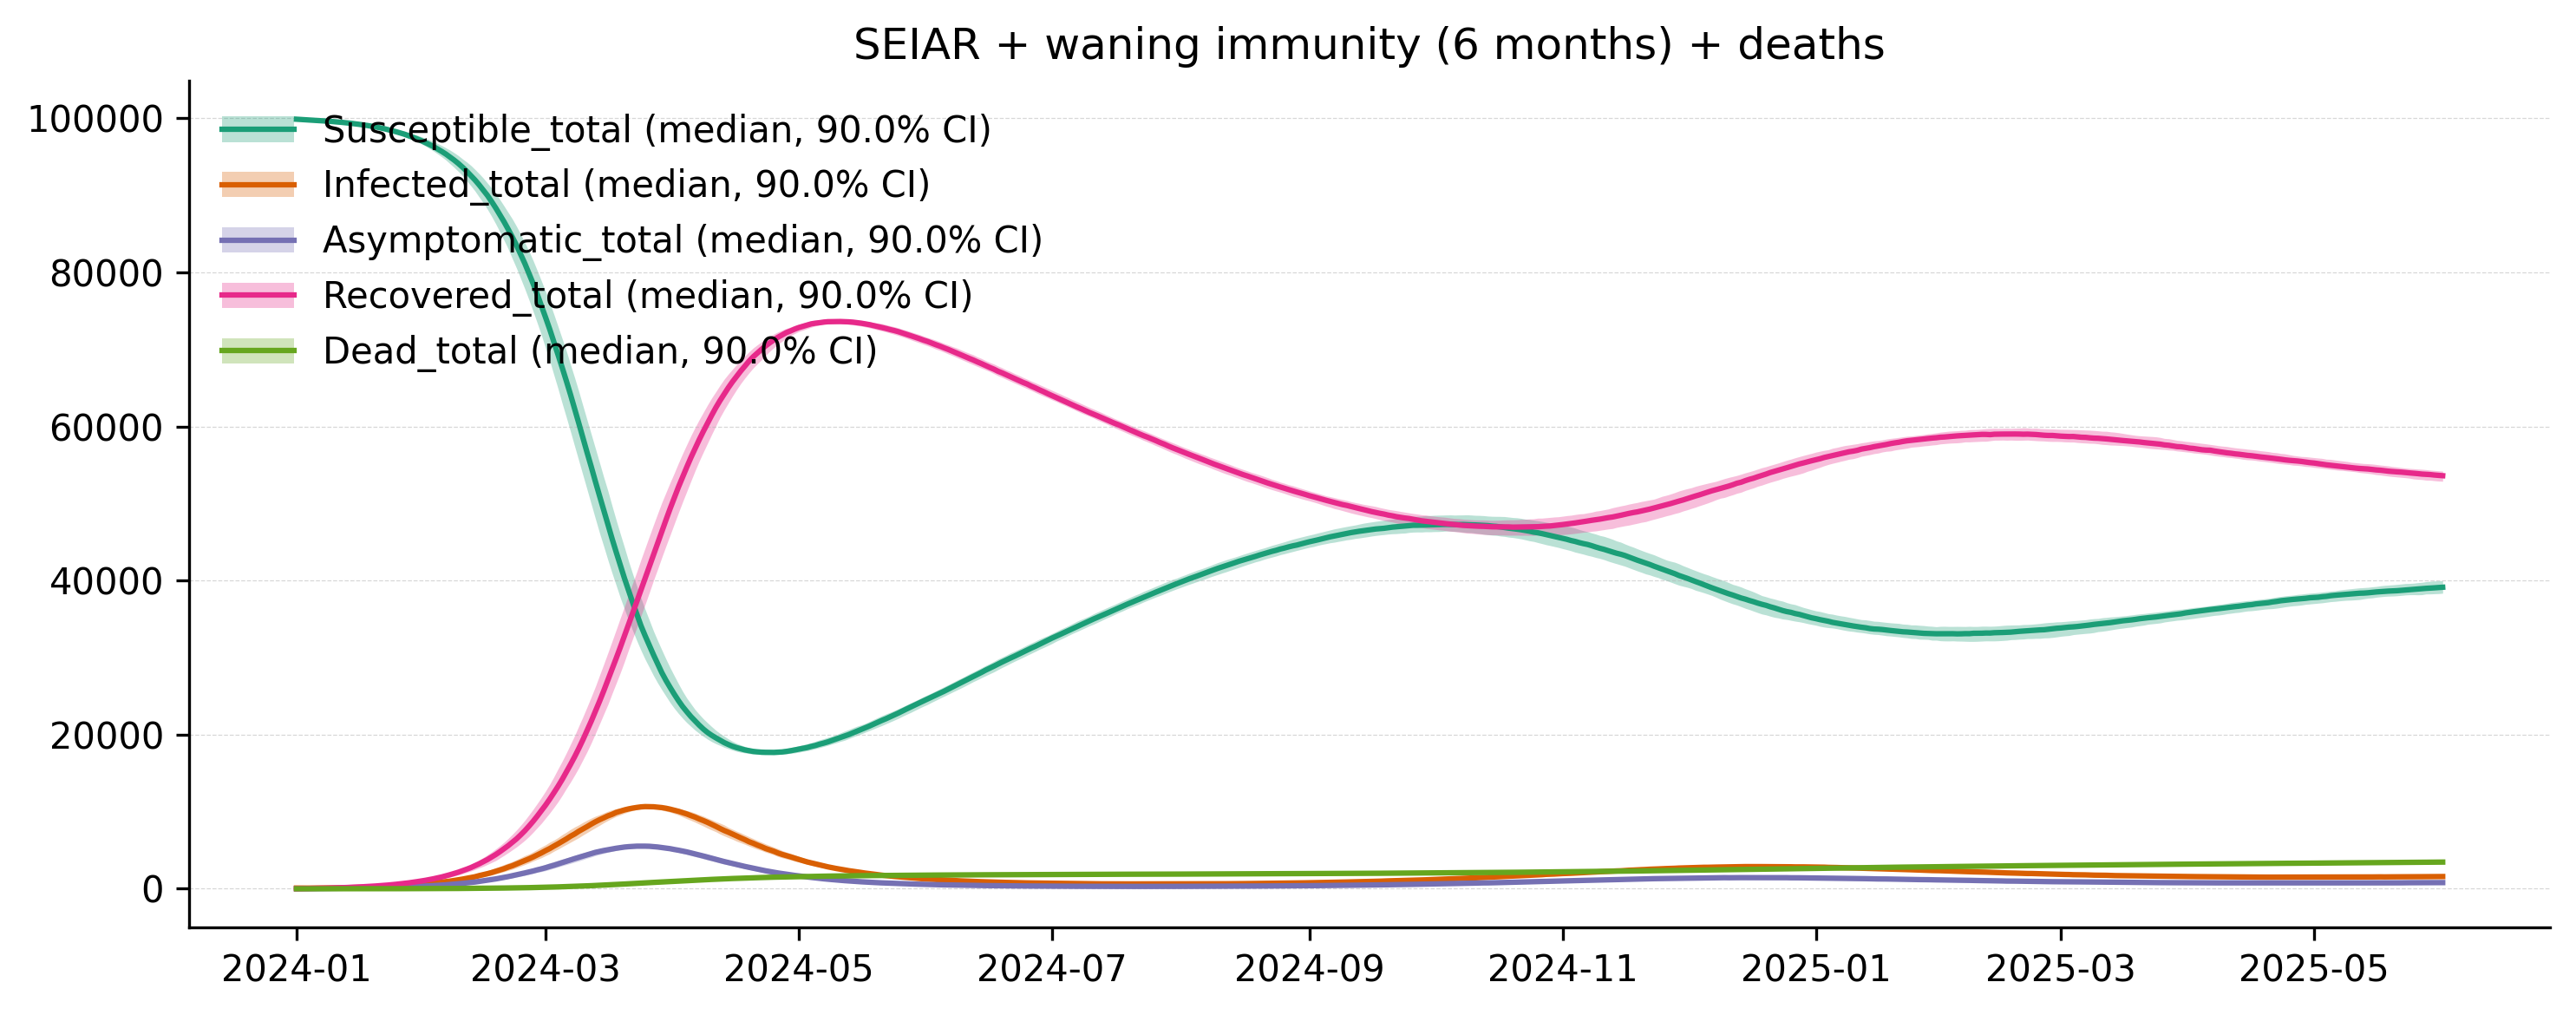

In [22]:
seiar_wd_results = seiar_wd.run_simulations(
    start_date="2024-01-01",
    end_date="2025-06-01",
    initial_conditions_dict={
        "Susceptible": np.array([99900]),
        "Exposed": np.array([0]),
        "Infected": np.array([100]),
        "Asymptomatic": np.array([0]),
        "Recovered": np.array([0]),
        "Dead": np.array([0]),
    },
)
df = seiar_wd_results.get_quantiles_compartments()
plot_quantiles(
    df,
    columns=["Susceptible_total", "Infected_total", "Asymptomatic_total",
             "Recovered_total", "Dead_total"],
    title="SEIAR + waning immunity (6 months) + deaths",
);

## 4. Overriding Parameters After Construction

All rate parameters accept scalars, **1D arrays** of shape `(T,)` for time-varying values, or **2D arrays** of shape `(T, G)` for age-stratified values. The scalar defaults in `load_predefined_model` are convenience values — they can be replaced after construction via `add_parameter`.

This is particularly useful for the modular parameters. For example, a `vaccination_rate` that ramps up over time, or a `waning_rate` that differs across age groups, are both straightforward to express.

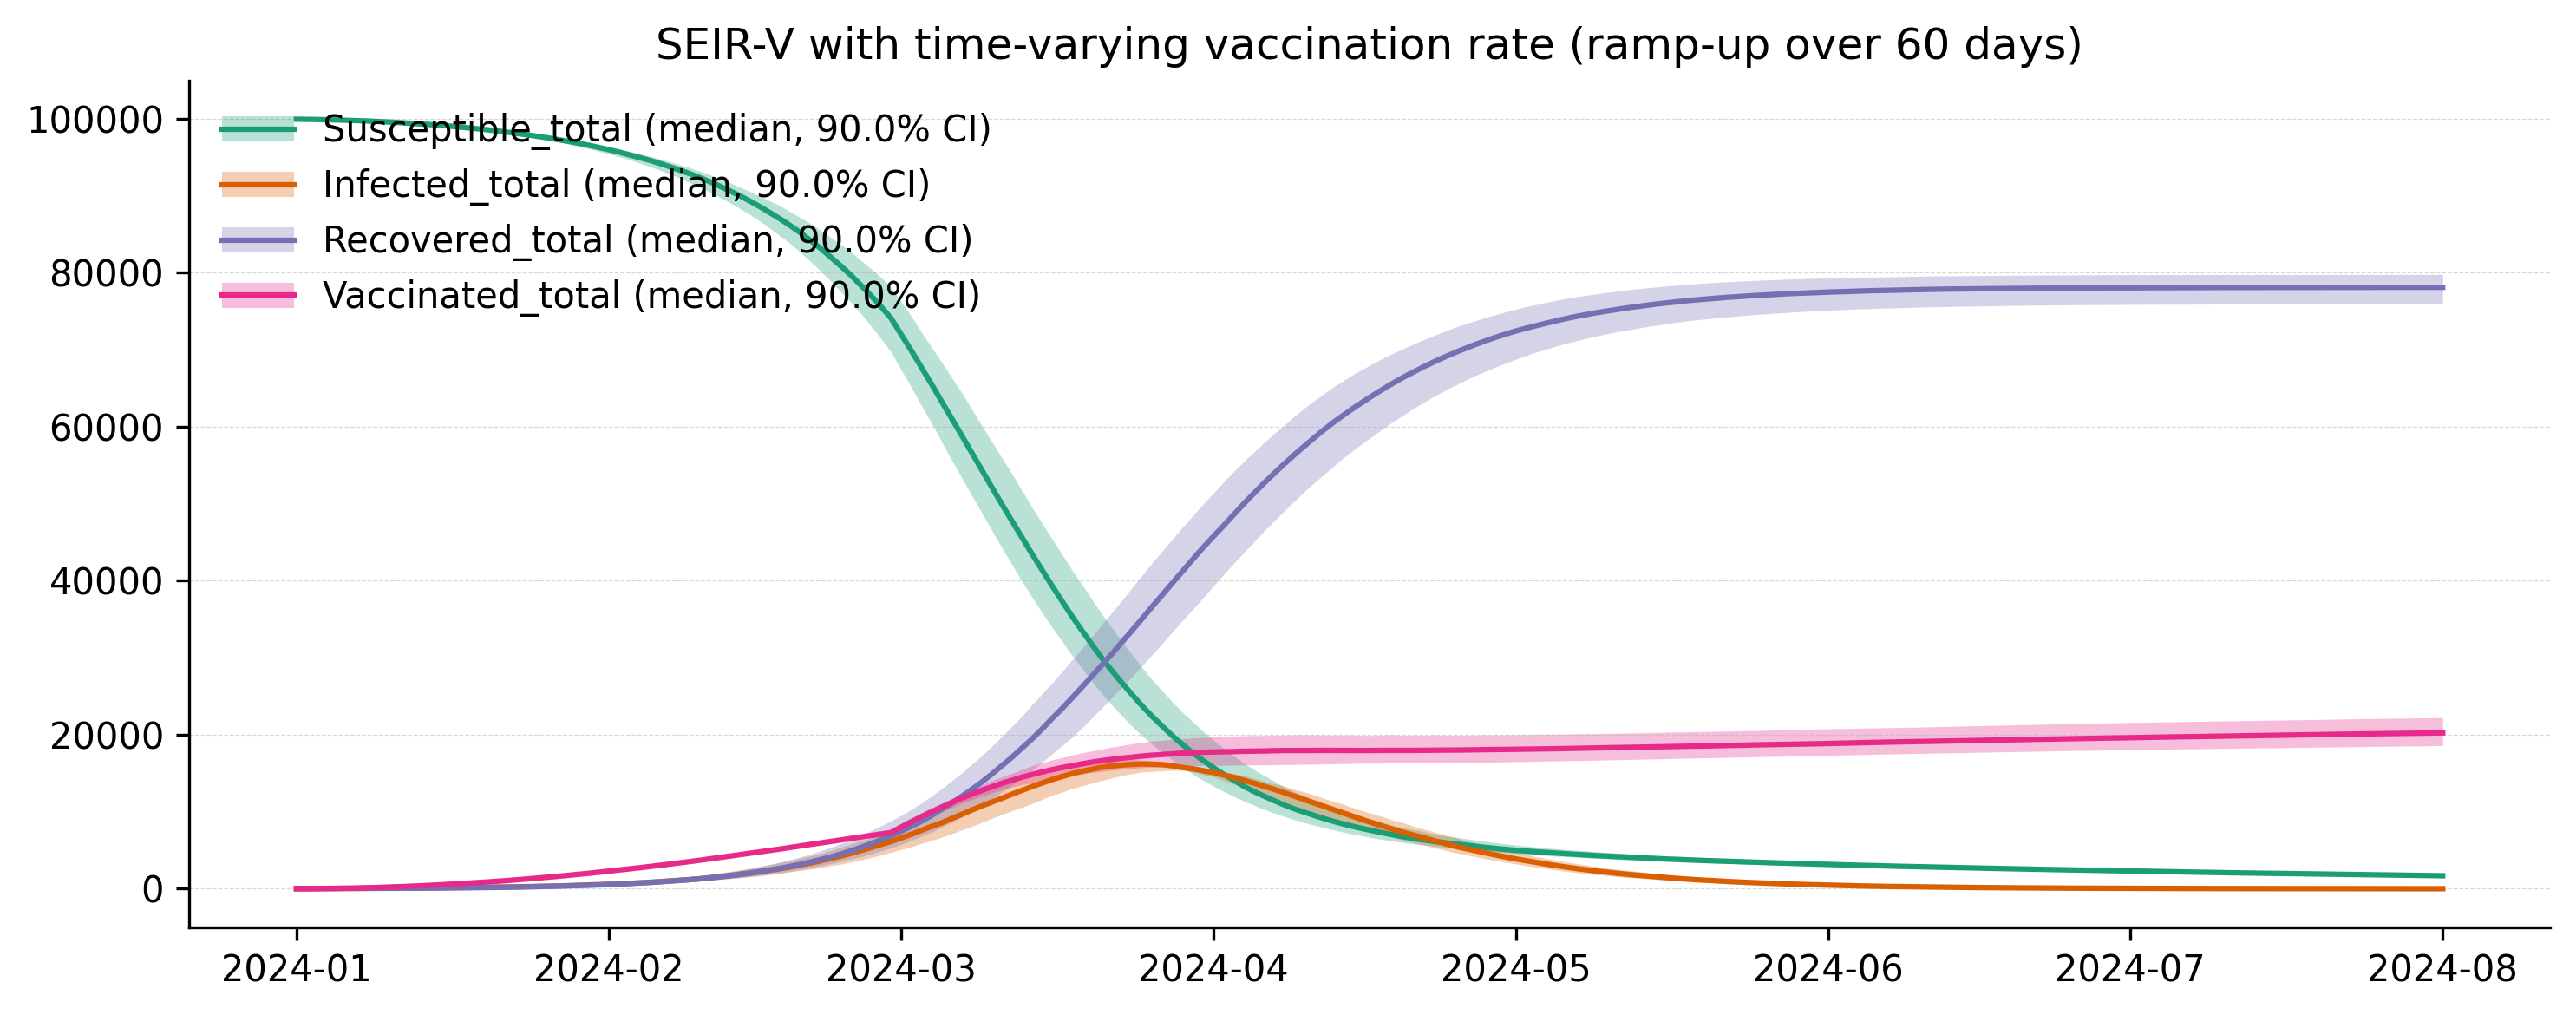

In [23]:
from epydemix.utils import compute_simulation_dates

start_date, end_date = "2024-01-01", "2024-08-01"
dates = compute_simulation_dates(start_date=start_date, end_date=end_date)
T = len(dates)

# Vaccination campaign: starts at 0, ramps up linearly over 60 days, then plateaus
vaccination_rate = np.clip(np.linspace(0, 0.01, T), 0, 0.01)
vaccination_rate[60:] = 0.01

model = load_predefined_model(
    "SEIR",
    transmission_rate=0.3,
    incubation_rate=0.2,
    recovery_rate=0.1,
    vaccination=True,
    vaccine_efficacy=0.85,
)

# Replace the scalar default with the time-varying array
model.add_parameter(parameter_name="vaccination_rate", value=vaccination_rate)

results = model.run_simulations(start_date=start_date, end_date=end_date)
df = results.get_quantiles_compartments()
plot_quantiles(
    df,
    columns=["Susceptible_total", "Infected_total", "Recovered_total", "Vaccinated_total"],
    title="SEIR-V with time-varying vaccination rate (ramp-up over 60 days)",
);

## Summary

The table below lists every common named model and its corresponding `load_predefined_model` call:

| Common name | Call |
|-------------|------|
| SIR  | `load_predefined_model("SIR")` |
| SEIR | `load_predefined_model("SEIR")` |
| SIS  | `load_predefined_model("SIS")` |
| SEIAR | `load_predefined_model("SEIAR")` |
| SIRS | `load_predefined_model("SIR", waning_immunity=True)` |
| SEIRS | `load_predefined_model("SEIR", waning_immunity=True)` |
| SEIR-V | `load_predefined_model("SEIR", vaccination=True)` |
| SIRD | `load_predefined_model("SIR", outcome="deaths")` |
| SEIRD | `load_predefined_model("SEIR", outcome="deaths")` |
| SEIRH | `load_predefined_model("SEIR", outcome="hospitalization")` |
| SEIRS-V | `load_predefined_model("SEIR", waning_immunity=True, vaccination=True)` |
| SEIAR + waning + deaths | `load_predefined_model("SEIAR", waning_immunity=True, outcome="deaths")` |

For any model not in this list, you can always define a custom model from scratch using `EpiModel` directly — see [Tutorial 1](./01_Model_Definition_and_Simulation.ipynb) and [Tutorial 6](./06_Advanced_Modeling_Features.ipynb).